In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import re
import os
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')

In [12]:
full_df = pd.read_csv(r"C:\Users\megha\Downloads\Projects\Duplicate Pairs Recognition\train.csv")
full_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [19]:
df = full_df.sample(30000)

In [20]:
df.reset_index(inplace = True)

In [21]:
df

,index,id,qid1,qid2,question1,question2,is_duplicate
0,218205,218205,324744,324745,Should India have multiple time zones?,Is it feasible for India to have multiple time...,1
1,283787,283787,68360,16049,How do I earn more coins in 8 ball pool?,How can I earn 8 ball pool cash?,1
2,313496,313496,189183,55528,"If I went back in time, and was killed, would ...","If I went back in time and killed myself, what...",1
3,153903,153903,241470,241471,What is the difference between a static variab...,Initialization of static variables? What is th...,1
4,175597,175597,270335,270336,"What does the French word ""Bof"" mean in English","What does the French word ""pourquoi"" mean in E...",0
...,...,...,...,...,...,...,...
29995,268797,268797,38255,144871,How can I lose weight fast and never gain it a...,Is there a technique to lose weight fast?,1
29996,303776,303776,426961,426962,How did the pentadactyl limb evolve?,How and why did the pentadactyl limb evolve?,1
29997,393156,393156,525915,525916,What would life in America be like without the...,What rights are not stated in the Bill of Rights?,0
29998,387262,387262,104804,133963,Which are the best short stories?,What are some really great short stories?,1


In [22]:
df.drop(columns = ['index','id','qid1','qid2'],axis = 1,inplace = True)

In [23]:
df

,question1,question2,is_duplicate
0,Should India have multiple time zones?,Is it feasible for India to have multiple time...,1
1,How do I earn more coins in 8 ball pool?,How can I earn 8 ball pool cash?,1
2,"If I went back in time, and was killed, would ...","If I went back in time and killed myself, what...",1
3,What is the difference between a static variab...,Initialization of static variables? What is th...,1
4,"What does the French word ""Bof"" mean in English","What does the French word ""pourquoi"" mean in E...",0
...,...,...,...
29995,How can I lose weight fast and never gain it a...,Is there a technique to lose weight fast?,1
29996,How did the pentadactyl limb evolve?,How and why did the pentadactyl limb evolve?,1
29997,What would life in America be like without the...,What rights are not stated in the Bill of Rights?,0
29998,Which are the best short stories?,What are some really great short stories?,1


In [24]:
df['is_duplicate'].value_counts(normalize = True)

is_duplicate
0    0.632
1    0.368
Name: proportion, dtype: float64

In [25]:
df

,question1,question2,is_duplicate
0,Should India have multiple time zones?,Is it feasible for India to have multiple time...,1
1,How do I earn more coins in 8 ball pool?,How can I earn 8 ball pool cash?,1
2,"If I went back in time, and was killed, would ...","If I went back in time and killed myself, what...",1
3,What is the difference between a static variab...,Initialization of static variables? What is th...,1
4,"What does the French word ""Bof"" mean in English","What does the French word ""pourquoi"" mean in E...",0
...,...,...,...
29995,How can I lose weight fast and never gain it a...,Is there a technique to lose weight fast?,1
29996,How did the pentadactyl limb evolve?,How and why did the pentadactyl limb evolve?,1
29997,What would life in America be like without the...,What rights are not stated in the Bill of Rights?,0
29998,Which are the best short stories?,What are some really great short stories?,1


Preprocess the Data

In [27]:
def preprocess(q):
    
    q = str(q).lower().strip()
    
    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    
    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')
    
    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    
    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")
    
    # Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()
    
    # Remove punctuations
    pattern = re.compile('\W')
    q = re.sub(pattern, ' ', q).strip()

    
    return q

In [28]:
df['question1'] = df['question1'].apply(lambda x: preprocess(x))
df['question2'] = df['question2'].apply(lambda x: preprocess(x))

In [30]:
df['q1_len'] = df['question1'].str.len() 
df['q2_len'] = df['question2'].str.len()

In [32]:
df['q1_num_words'] = df['question1'].apply(lambda row: len(row.split(" ")))
df['q2_num_words'] = df['question2'].apply(lambda row: len(row.split(" ")))
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
0,should india have multiple time zones,is it feasible for india to have multiple time...,1,37,51,6,10
1,how do i earn more coins in 8 ball pool,how can i earn 8 ball pool cash,1,39,31,10,8
2,if i went back in time and was killed would ...,if i went back in time and killed myself what...,1,66,59,17,13
3,what is the difference between a static variab...,initialization of static variables what is th...,1,75,111,14,19
4,what does the french word bof mean in english,what does the french word pourquoi mean in e...,0,47,52,11,11


In [33]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [34]:
df['word_common'] = df.apply(common_words, axis=1)
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
0,should india have multiple time zones,is it feasible for india to have multiple time...,1,37,51,6,10,4
1,how do i earn more coins in 8 ball pool,how can i earn 8 ball pool cash,1,39,31,10,8,6
2,if i went back in time and was killed would ...,if i went back in time and killed myself what...,1,66,59,17,13,10
3,what is the difference between a static variab...,initialization of static variables what is th...,1,75,111,14,19,12
4,what does the french word bof mean in english,what does the french word pourquoi mean in e...,0,47,52,11,11,9


In [35]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [38]:
df['word_total'] = df.apply(total_words, axis=1)
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
0,should india have multiple time zones,is it feasible for india to have multiple time...,1,37,51,6,10,4,16
1,how do i earn more coins in 8 ball pool,how can i earn 8 ball pool cash,1,39,31,10,8,6,18
2,if i went back in time and was killed would ...,if i went back in time and killed myself what...,1,66,59,17,13,10,27
3,what is the difference between a static variab...,initialization of static variables what is th...,1,75,111,14,19,12,28
4,what does the french word bof mean in english,what does the french word pourquoi mean in e...,0,47,52,11,11,9,20


In [39]:
df['word_share'] = round(df['word_common']/df['word_total'],2)
df.head()

,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,should india have multiple time zones,is it feasible for india to have multiple time...,1,37,51,6,10,4,16,0.25
1,how do i earn more coins in 8 ball pool,how can i earn 8 ball pool cash,1,39,31,10,8,6,18,0.33
2,if i went back in time and was killed would ...,if i went back in time and killed myself what...,1,66,59,17,13,10,27,0.37
3,what is the difference between a static variab...,initialization of static variables what is th...,1,75,111,14,19,12,28,0.43
4,what does the french word bof mean in english,what does the french word pourquoi mean in e...,0,47,52,11,11,9,20,0.45


minimum characters 4
maximum characters 336
average num of characters 58


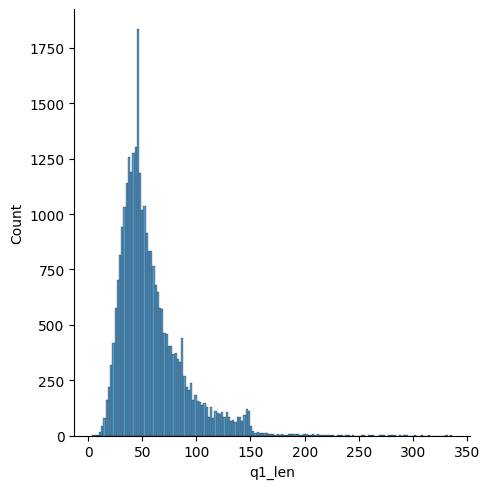

In [40]:
# Analysis of features
sns.displot(df['q1_len'])
print('minimum characters',df['q1_len'].min())
print('maximum characters',df['q1_len'].max())
print('average num of characters',int(df['q1_len'].mean()))

minimum characters 0
maximum characters 1170
average num of characters 58


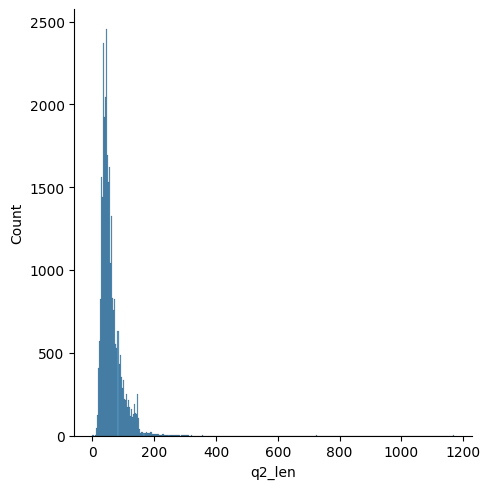

In [41]:
sns.displot(df['q2_len'])
print('minimum characters',df['q2_len'].min())
print('maximum characters',df['q2_len'].max())
print('average num of characters',int(df['q2_len'].mean()))

minimum words 1
maximum words 77
average num of words 11


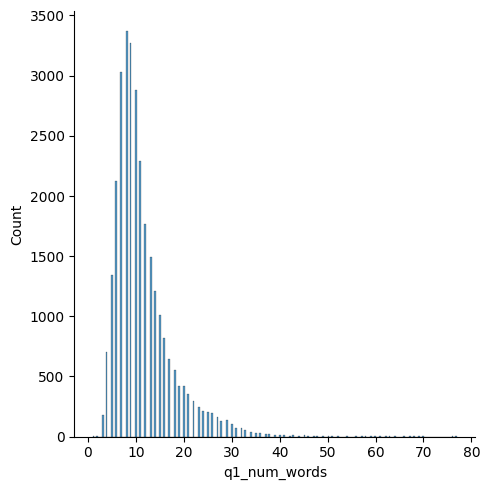

In [42]:
sns.displot(df['q1_num_words'])
print('minimum words',df['q1_num_words'].min())
print('maximum words',df['q1_num_words'].max())
print('average num of words',int(df['q1_num_words'].mean()))

minimum words 1
maximum words 264
average num of words 11


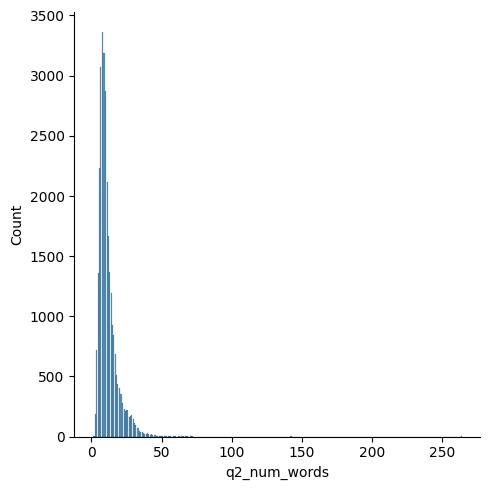

In [43]:
sns.displot(df['q2_num_words'])
print('minimum words',df['q2_num_words'].min())
print('maximum words',df['q2_num_words'].max())
print('average num of words',int(df['q2_num_words'].mean()))

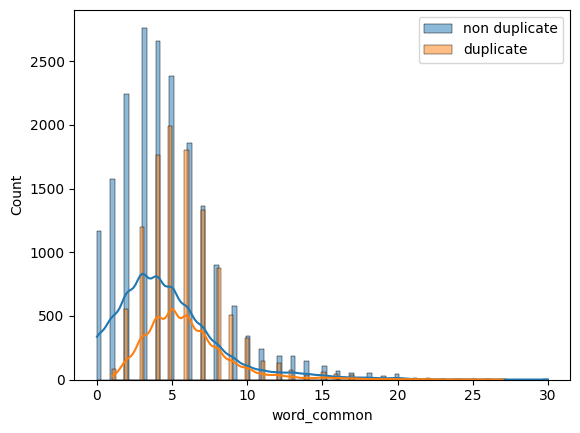

In [45]:
# common words
sns.histplot(df[df['is_duplicate'] == 0]['word_common'],label='non duplicate',kde = True)
sns.histplot(df[df['is_duplicate'] == 1]['word_common'],label='duplicate',kde = True)
plt.legend()
plt.show()

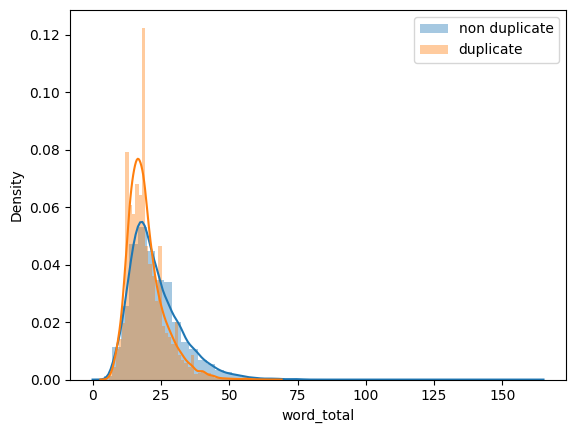

In [46]:
# total words
sns.distplot(df[df['is_duplicate'] == 0]['word_total'],label='non duplicate')
sns.distplot(df[df['is_duplicate'] == 1]['word_total'],label='duplicate')
plt.legend()
plt.show()

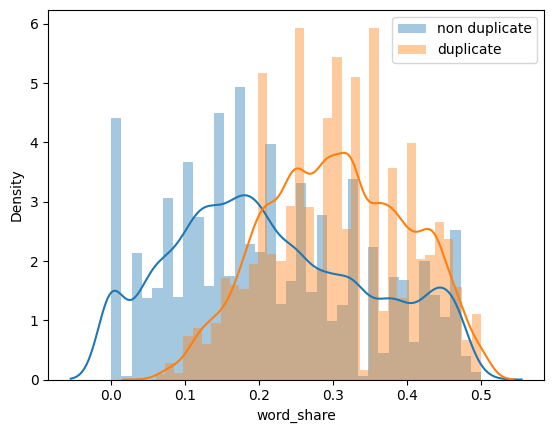

In [47]:
# word share
sns.distplot(df[df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(df[df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()